<a href="https://colab.research.google.com/github/eshghinezhad/DeepLearning/blob/master/Sequence%20Model/MAI202_A2_weather_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### MAI1202 Assignment 2 - Sequence Model
#### MonirehEshghinezhad - 150705234

In [2]:
import importlib.util
if importlib.util.find_spec("torchmetrics") is None:
    %pip install -q torchmetrics

from packaging.version import Version
import torch
assert Version(torch.__version__) >= Version("2.6.0")

import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torchmetrics
from sklearn.preprocessing import StandardScaler

plt.rc('font', size=13)
plt.rc('axes', labelsize=13, titlesize=13)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed()

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
device

'cuda'

## 2. Load & Explore the Dataset

In [4]:
df = pd.read_csv("weather_prediction_dataset.csv")

df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d")
df = df.set_index("DATE").sort_index()
dgf= df.drop_duplicates
print(f"Dataset shape: {df.shape}")
print(f"{len(df)} daily records from {df.index.min().date()} to {df.index.max().date()}")
print(f"Missing values: {df.isna().sum().sum()}")

df[["BASEL_temp_mean", "BASEL_humidity"]].describe()

Dataset shape: (3654, 164)
3654 daily records from 2000-01-01 to 2010-01-01
Missing values: 0


,BASEL_temp_mean,BASEL_humidity
count,3654.000000,3654.000000
mean,11.022797,0.745107
std,7.414754,0.107788
min,-9.300000,0.380000
25%,5.300000,0.670000
50%,11.400000,0.760000
75%,16.900000,0.830000
max,29.000000,0.980000


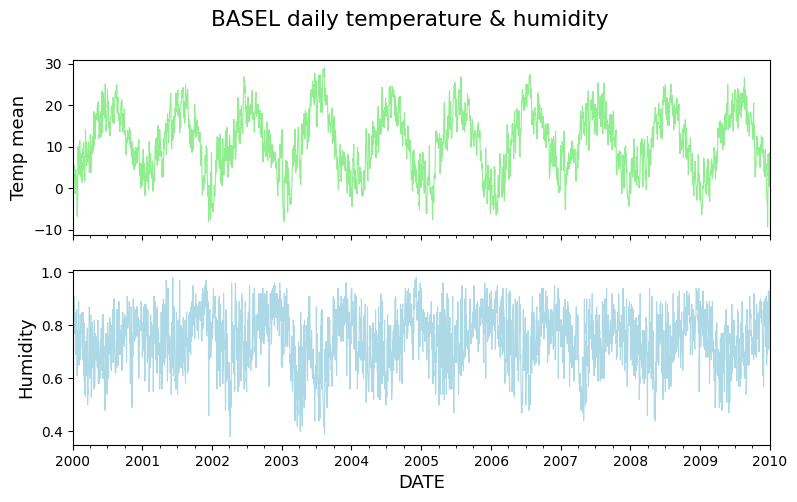

In [5]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
df["BASEL_temp_mean"].plot(ax=axs[0], color="lightgreen", linewidth=0.8)
axs[0].set_ylabel("Temp mean")
df["BASEL_humidity"].plot(ax=axs[1], color="lightblue", linewidth=0.8)
axs[1].set_ylabel("Humidity")
fig.suptitle("BASEL daily temperature & humidity")
plt.show()

## Preparing the Data for ML Models

In [6]:
class WindowedDataset(torch.utils.data.Dataset):
    def __init__(self, data, window_length, horizon, target_idx):
        self.data = torch.as_tensor(data, dtype=torch.float32)
        self.window_length = window_length
        self.horizon = horizon
        self.target_idx = target_idx

    def __len__(self):
        return len(self.data) - self.window_length - self.horizon + 1

    def __getitem__(self, idx):
        end = idx + self.window_length
        window = self.data[idx:end]                     # [window_length, n_features]
        future = self.data[end:end + self.horizon]       # [horizon, n_features]
        target = future[:, self.target_idx].reshape(-1)  # flatten -> [horizon * n_targets]
        return window, target

In [ ]:
def prepare_scenario(df, feature_cols, target_cols, window_length, horizon,
                      train_frac=0.70, valid_frac_of_train=0.15, batch_size=64):
    data = df[feature_cols].to_numpy(dtype="float32")
    n = len(data)
    n_train_total = int(n * train_frac)
    n_valid = int(n_train_total * valid_frac_of_train)
    n_train = n_train_total - n_valid

    train_raw = data[:n_train]
    valid_raw = data[n_train:n_train_total]
    test_raw = data[n_train_total:]

    scaler = StandardScaler().fit(train_raw)  # fit on TRAIN ONLY
    train_scaled = scaler.transform(train_raw)
    valid_scaled = scaler.transform(valid_raw)
    test_scaled = scaler.transform(test_raw)

    target_idx = [feature_cols.index(c) for c in target_cols]

    def make_loader(split, shuffle):
        ds = WindowedDataset(split, window_length, horizon, target_idx)
        return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    loaders = (make_loader(train_scaled, True),
               make_loader(valid_scaled, False),
               make_loader(test_scaled, False))
    return loaders, scaler, target_idx
